In [17]:
import os

# Use conda's newer libstdc++ instead of the system one
conda_lib = os.path.expanduser("~/.conda/envs/hnn-core-env/lib")
ld_path = os.environ.get("LD_LIBRARY_PATH", "")
os.environ["LD_LIBRARY_PATH"] = f"{conda_lib}:{ld_path}"

# UCX settings (from before)
os.environ["UCX_TLS"] = "tcp,self,sm"
os.environ["UCX_NET_DEVICES"] = "all"


# MPI paths
mpi_bin = "/oscar/rt/sw/external/hpcx-mpi/2.25.1/bin"
mpi_lib = "/oscar/rt/sw/external/hpcx-mpi/2.25.1/lib"
if mpi_bin not in os.environ["PATH"]:
    os.environ["PATH"] = f"{mpi_bin}:{os.environ['PATH']}"
if mpi_lib not in ld_path:
    os.environ["LD_LIBRARY_PATH"] = f"{mpi_lib}:{os.environ['LD_LIBRARY_PATH']}"

import sys
# Add MPI bin directory to PATH
mpi_bin = "/oscar/rt/sw/external/hpcx-mpi/2.25.1/bin"
if mpi_bin not in os.environ["PATH"]:
    os.environ["PATH"] = f"{mpi_bin}:{os.environ['PATH']}"

# print("Updated PATH to include MPI")
# print("MPI location:", mpi_bin)

import os
print("PATH:", os.environ.get('PATH', 'NOT SET'))
print("Which mpiexec:")
import subprocess
result = subprocess.run(['which', 'mpiexec'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else "mpiexec not found")

PATH: /oscar/rt/sw/external/hpcx-mpi/2.25.1/bin:/oscar/home/xgao35/venvs/hnn-core-calcium-202602/bin:/users/xgao35/.pixi/bin:/users/xgao35/.conda/envs/hnn_core/bin:/oscar/runtime/bin:/oscar/runtime/ood_system/desktop/bin:/oscar/runtime/ood_system/desktop/websockify/websockify-venv/bin:/oscar/runtime/ood_system/xfce-desktop/4.18/bin:/users/xgao35/.pixi/bin:/users/xgao35/miniconda3/condabin:/users/xgao35/.conda/envs/hnn_core/bin:/usr/local/bin:/usr/bin:/usr/local/sbin:/usr/sbin:/usr/lpp/mmfs/bin:/usr/lpp/mmfs/sbin:/users/xgao35/bin
Which mpiexec:
/oscar/rt/sw/external/hpcx-mpi/2.25.1/bin/mpiexec



In [18]:
import os.path as op

import matplotlib.pyplot as plt

from hnn_core import calcium_model, read_params, simulate_dipole, average_dipoles, read_dipole
from hnn_core.hnn_io import read_network_configuration
from hnn_core.network_models import duecker_ET_model
from hnn_core.viz import plot_dipole
import matplotlib.pyplot as plt
from copy import deepcopy
import pandas as pd
import pickle
import numpy as np
from hnn_core import MPIBackend
import json

In [20]:
# load BETA4 net 
with open('/users/xgao35/Desktop/HNN_TEP/Networks/BETA4_100_calcium_202602_optim.pkl', 'rb') as f:
    BETA4_net = pickle.load(f)

# load BETA4 double pulse (100)
df = pd.read_csv('/users/xgao35/Desktop/HNN_TEP/Data/BETA04_5mm_ROI_STC_100MT_DOUBLE.txt', sep = ' ')
BETA4_double_TEP_data = [df.iloc[:,0].tolist(), df.iloc[:,1].tolist()]
BETA4_double_TEP_data[0] = [x * 1000 for x in BETA4_double_TEP_data[0]]
BETA4_double_TEP_data[1] = [y * 1e9 for y in BETA4_double_TEP_data[1]]

In [21]:
def scale_and_smooth(dpls, window_len=10, scaling_factor=0.3):
    dpls_smoothed = deepcopy(dpls)
    for dpl in dpls_smoothed:
        dpl.smooth(window_len).scale(scaling_factor)
    return dpls_smoothed
    from hnn_core.viz import plot_spikes_raster

In [22]:
r_net = deepcopy(BETA4_net)

In [23]:
t = 100

r_net.add_evoked_drive('evprox4',
                    mu=r_net.external_drives['evprox1']['dynamics']['mu'] + t,
                    sigma=r_net.external_drives['evprox1']['dynamics']['sigma'],
                    numspikes=r_net.external_drives['evprox1']['dynamics']['numspikes'],
                    location='proximal',
                    weights_ampa=r_net.external_drives['evprox1']['weights_ampa'], 
                    weights_nmda=r_net.external_drives['evprox1']['weights_nmda'],
                    synaptic_delays=r_net.external_drives['evprox1']['synaptic_delays'])

# copy evprox 2
r_net.add_evoked_drive('evprox5',
                mu=r_net.external_drives['evprox2']['dynamics']['mu'] + t,
                sigma=r_net.external_drives['evprox2']['dynamics']['sigma'],
                numspikes=r_net.external_drives['evprox2']['dynamics']['numspikes'],
                location='proximal',
                weights_ampa=r_net.external_drives['evprox2']['weights_ampa'], 
                weights_nmda=r_net.external_drives['evprox2']['weights_nmda'],
                synaptic_delays=r_net.external_drives['evprox2']['synaptic_delays'])

# copy evprox 3
r_net.add_evoked_drive('evprox6',
                mu=r_net.external_drives['evprox3']['dynamics']['mu'] + t,
                sigma=r_net.external_drives['evprox3']['dynamics']['sigma'],
                numspikes=r_net.external_drives['evprox3']['dynamics']['numspikes'],
                location='proximal',
                weights_ampa=r_net.external_drives['evprox3']['weights_ampa'], 
                weights_nmda=r_net.external_drives['evprox3']['weights_nmda'],
                synaptic_delays=r_net.external_drives['evprox3']['synaptic_delays'])

# copy evdist 1 
r_net.add_evoked_drive('evdist4',
                mu=r_net.external_drives['evdist1']['dynamics']['mu'] + t,
                sigma=r_net.external_drives['evdist1']['dynamics']['sigma'],
                numspikes=r_net.external_drives['evdist1']['dynamics']['numspikes'],
                location='distal',
                weights_ampa=r_net.external_drives['evdist1']['weights_ampa'], 
                weights_nmda=r_net.external_drives['evdist1']['weights_nmda'],
                synaptic_delays=r_net.external_drives['evdist1']['synaptic_delays'])

# copy evdist 2 
r_net.add_evoked_drive('evdist5',
                mu=r_net.external_drives['evdist2']['dynamics']['mu'] + t,
                sigma=r_net.external_drives['evdist2']['dynamics']['sigma'],
                numspikes=r_net.external_drives['evdist2']['dynamics']['numspikes'],
                location='distal',
                weights_ampa=r_net.external_drives['evdist2']['weights_ampa'], 
                weights_nmda=r_net.external_drives['evdist2']['weights_nmda'],
                synaptic_delays=r_net.external_drives['evdist2']['synaptic_delays'])

# copy evdist 3
r_net.add_evoked_drive('evdist6',
                mu=r_net.external_drives['evdist3']['dynamics']['mu'] + t,
                sigma=r_net.external_drives['evdist3']['dynamics']['sigma'],
                numspikes=r_net.external_drives['evdist3']['dynamics']['numspikes'],
                location='distal',
                weights_ampa=r_net.external_drives['evdist3']['weights_ampa'], 
                weights_nmda=r_net.external_drives['evdist3']['weights_nmda'],
                synaptic_delays=r_net.external_drives['evdist3']['synaptic_delays'])


In [24]:
TEP_100_dpl = simulate_dipole(r_net, tstop=350, n_trials=3,bsl_cor='duecker')

Joblib will run 3 trial(s) in parallel by distributing trials over 1 jobs.
Building the NEURON model
[Done]
Trial 1: 0.03 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...
Trial 1: 100.0 ms...
Trial 1: 110.0 ms...
Trial 1: 120.0 ms...
Trial 1: 130.0 ms...
Trial 1: 140.0 ms...
Trial 1: 150.0 ms...
Trial 1: 160.0 ms...
Trial 1: 170.0 ms...
Trial 1: 180.0 ms...
Trial 1: 190.0 ms...
Trial 1: 200.0 ms...
Trial 1: 210.0 ms...
Trial 1: 220.0 ms...
Trial 1: 230.0 ms...
Trial 1: 240.0 ms...
Trial 1: 250.0 ms...
Trial 1: 260.0 ms...
Trial 1: 270.0 ms...
Trial 1: 280.0 ms...
Trial 1: 290.0 ms...
Trial 1: 300.0 ms...
Trial 1: 310.0 ms...
Trial 1: 320.0 ms...
Trial 1: 330.0 ms...
Trial 1: 340.0 ms...
Building the NEURON model
[Done]
Trial 2: 0.03 ms...
Trial 2: 10.0 ms...
Trial 2: 20.0 ms...
Trial 2: 30.0 ms...
Trial 2: 40.0 ms...
Trial 2: 50.0 ms...
Trial 2: 60.0 

IOStream.flush timed out
IOStream.flush timed out


Trial 3: 140.0 ms...
Trial 3: 150.0 ms...
Trial 3: 160.0 ms...
Trial 3: 170.0 ms...
Trial 3: 180.0 ms...
Trial 3: 190.0 ms...
Trial 3: 200.0 ms...
Trial 3: 210.0 ms...
Trial 3: 220.0 ms...
Trial 3: 230.0 ms...
Trial 3: 240.0 ms...
Trial 3: 250.0 ms...
Trial 3: 260.0 ms...
Trial 3: 270.0 ms...
Trial 3: 280.0 ms...
Trial 3: 290.0 ms...
Trial 3: 300.0 ms...
Trial 3: 310.0 ms...
Trial 3: 320.0 ms...
Trial 3: 330.0 ms...
Trial 3: 340.0 ms...


IOStream.flush timed out
IOStream.flush timed out


Applying calcium model baseline correction
Applying calcium model baseline correction
Applying calcium model baseline correction


In [25]:
TEP_dpl = simulate_dipole(BETA4_net, tstop=350, n_trials=1,bsl_cor='duecker')

Joblib will run 1 trial(s) in parallel by distributing trials over 1 jobs.
Building the NEURON model
[Done]
Trial 1: 0.03 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...
Trial 1: 100.0 ms...
Trial 1: 110.0 ms...
Trial 1: 120.0 ms...
Trial 1: 130.0 ms...
Trial 1: 140.0 ms...
Trial 1: 150.0 ms...
Trial 1: 160.0 ms...
Trial 1: 170.0 ms...
Trial 1: 180.0 ms...
Trial 1: 190.0 ms...
Trial 1: 200.0 ms...
Trial 1: 210.0 ms...
Trial 1: 220.0 ms...
Trial 1: 230.0 ms...
Trial 1: 240.0 ms...
Trial 1: 250.0 ms...
Trial 1: 260.0 ms...
Trial 1: 270.0 ms...
Trial 1: 280.0 ms...
Trial 1: 290.0 ms...
Trial 1: 300.0 ms...
Trial 1: 310.0 ms...
Trial 1: 320.0 ms...
Trial 1: 330.0 ms...
Trial 1: 340.0 ms...
Applying calcium model baseline correction


In [26]:
t = 100

plot_net_100 = deepcopy(BETA4_net)
plot_net_100.clear_drives()

plot_net_100.add_evoked_drive('evprox4',
                    mu=r_net.external_drives['evprox1']['dynamics']['mu'] + t,
                    sigma=r_net.external_drives['evprox1']['dynamics']['sigma'],
                    numspikes=r_net.external_drives['evprox1']['dynamics']['numspikes'],
                    location='proximal',
                    weights_ampa=r_net.external_drives['evprox1']['weights_ampa'], 
                    weights_nmda=r_net.external_drives['evprox1']['weights_nmda'],
                    synaptic_delays=r_net.external_drives['evprox1']['synaptic_delays'])

# copy evprox 2
plot_net_100.add_evoked_drive('evprox5',
                mu=r_net.external_drives['evprox2']['dynamics']['mu'] + t,
                sigma=r_net.external_drives['evprox2']['dynamics']['sigma'],
                numspikes=r_net.external_drives['evprox2']['dynamics']['numspikes'],
                location='proximal',
                weights_ampa=r_net.external_drives['evprox2']['weights_ampa'], 
                weights_nmda=r_net.external_drives['evprox2']['weights_nmda'],
                synaptic_delays=r_net.external_drives['evprox2']['synaptic_delays'])

# copy evprox 3
plot_net_100.add_evoked_drive('evprox6',
                mu=r_net.external_drives['evprox3']['dynamics']['mu'] + t,
                sigma=r_net.external_drives['evprox3']['dynamics']['sigma'],
                numspikes=r_net.external_drives['evprox3']['dynamics']['numspikes'],
                location='proximal',
                weights_ampa=r_net.external_drives['evprox3']['weights_ampa'], 
                weights_nmda=r_net.external_drives['evprox3']['weights_nmda'],
                synaptic_delays=r_net.external_drives['evprox3']['synaptic_delays'])

# copy evdist 1 
plot_net_100.add_evoked_drive('evdist4',
                mu=r_net.external_drives['evdist1']['dynamics']['mu'] + t,
                sigma=r_net.external_drives['evdist1']['dynamics']['sigma'],
                numspikes=r_net.external_drives['evdist1']['dynamics']['numspikes'],
                location='distal',
                weights_ampa=r_net.external_drives['evdist1']['weights_ampa'], 
                weights_nmda=r_net.external_drives['evdist1']['weights_nmda'],
                synaptic_delays=r_net.external_drives['evdist1']['synaptic_delays'])

# copy evdist 2 
plot_net_100.add_evoked_drive('evdist5',
                mu=r_net.external_drives['evdist2']['dynamics']['mu'] + t,
                sigma=r_net.external_drives['evdist2']['dynamics']['sigma'],
                numspikes=r_net.external_drives['evdist2']['dynamics']['numspikes'],
                location='distal',
                weights_ampa=r_net.external_drives['evdist2']['weights_ampa'], 
                weights_nmda=r_net.external_drives['evdist2']['weights_nmda'],
                synaptic_delays=r_net.external_drives['evdist2']['synaptic_delays'])

# copy evdist 3
plot_net_100.add_evoked_drive('evdist6',
                mu=r_net.external_drives['evdist3']['dynamics']['mu'] + t,
                sigma=r_net.external_drives['evdist3']['dynamics']['sigma'],
                numspikes=r_net.external_drives['evdist3']['dynamics']['numspikes'],
                location='distal',
                weights_ampa=r_net.external_drives['evdist3']['weights_ampa'], 
                weights_nmda=r_net.external_drives['evdist3']['weights_nmda'],
                synaptic_delays=r_net.external_drives['evdist3']['synaptic_delays'])


In [27]:
plot_net_100_dpl = simulate_dipole(plot_net_100, tstop=350, n_trials=1,bsl_cor='duecker')

Joblib will run 1 trial(s) in parallel by distributing trials over 1 jobs.
Building the NEURON model
[Done]
Trial 1: 0.03 ms...
Trial 1: 10.0 ms...
Trial 1: 20.0 ms...
Trial 1: 30.0 ms...
Trial 1: 40.0 ms...
Trial 1: 50.0 ms...
Trial 1: 60.0 ms...
Trial 1: 70.0 ms...
Trial 1: 80.0 ms...
Trial 1: 90.0 ms...
Trial 1: 100.0 ms...
Trial 1: 110.0 ms...
Trial 1: 120.0 ms...
Trial 1: 130.0 ms...
Trial 1: 140.0 ms...
Trial 1: 150.0 ms...
Trial 1: 160.0 ms...
Trial 1: 170.0 ms...
Trial 1: 180.0 ms...
Trial 1: 190.0 ms...
Trial 1: 200.0 ms...
Trial 1: 210.0 ms...
Trial 1: 220.0 ms...
Trial 1: 230.0 ms...
Trial 1: 240.0 ms...
Trial 1: 250.0 ms...
Trial 1: 260.0 ms...
Trial 1: 270.0 ms...
Trial 1: 280.0 ms...
Trial 1: 290.0 ms...
Trial 1: 300.0 ms...
Trial 1: 310.0 ms...
Trial 1: 320.0 ms...
Trial 1: 330.0 ms...
Trial 1: 340.0 ms...
Applying calcium model baseline correction


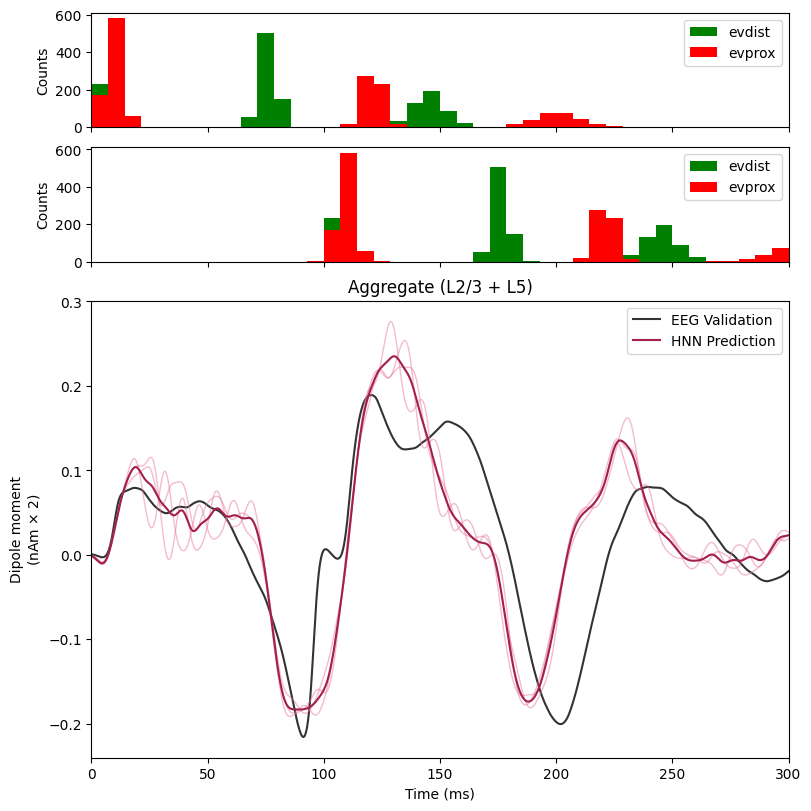

In [30]:
TEP_100_dpl_smoothed = scale_and_smooth(TEP_100_dpl, scaling_factor=2.5,window_len=10)

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(8, 8), constrained_layout=True, height_ratios=[1,1,4])
tstop=300
data_scale = 1

# plot 1: drives
BETA4_net.cell_response.plot_spikes_hist(ax=axes[0], spike_types=['evprox','evdist'], trial_idx=0, show=False)
axes[0].set_xlim(0,tstop)

# plot 2: drives 2
plot_net_100.cell_response.plot_spikes_hist(ax=axes[1], spike_types=['evprox','evdist'], trial_idx=0, show=False)
axes[1].set_xlim(0,tstop)

# plot 3: dipoles and data

TEP_100_dpl_smoothed_copy = deepcopy(TEP_100_dpl_smoothed)
axes[2].plot(np.array(BETA4_double_TEP_data[0][:tstop*10]), np.array(BETA4_double_TEP_data[1][:tstop*10])*data_scale,label='EEG Validation',color='k',alpha=0.8)
plot_dipole(TEP_100_dpl_smoothed_copy, ax = axes[2], layer='agg', show=False, average=True,label='HNN Prediction',color='#A41E4F')

axes[2].legend()
axes[2].set_xlim(0,tstop)

plt.savefig('TEP_double_100.png')
